In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [5]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [6]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [7]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [8]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [9]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [10]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [11]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [12]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [13]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [14]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [15]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [17]:
# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [18]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [20]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [21]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [22]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [23]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

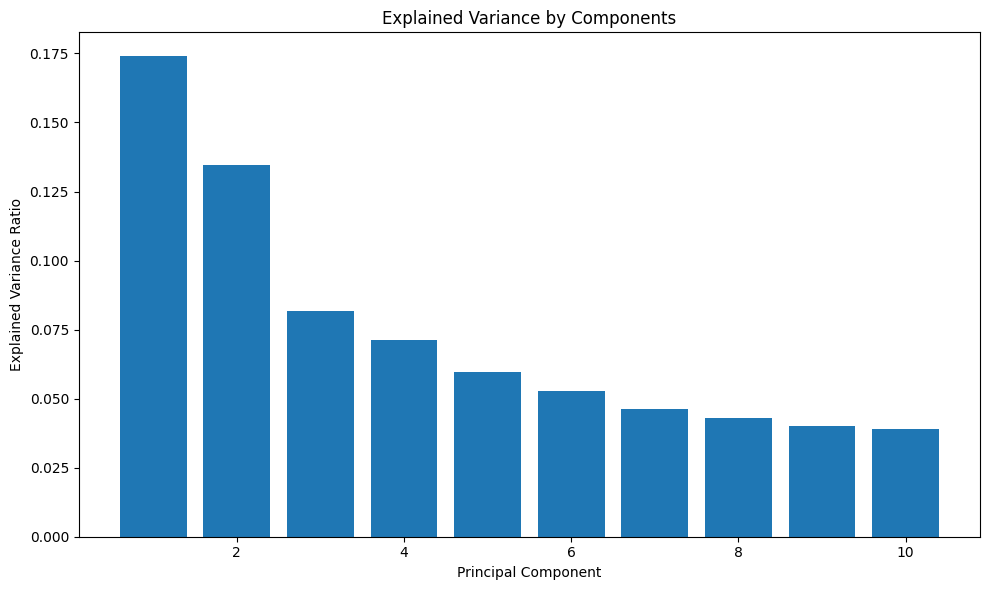

In [24]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [25]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [26]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

In [27]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [28]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

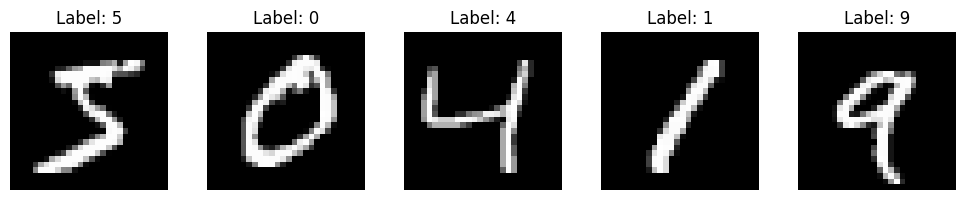

In [29]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [30]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    # brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [31]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

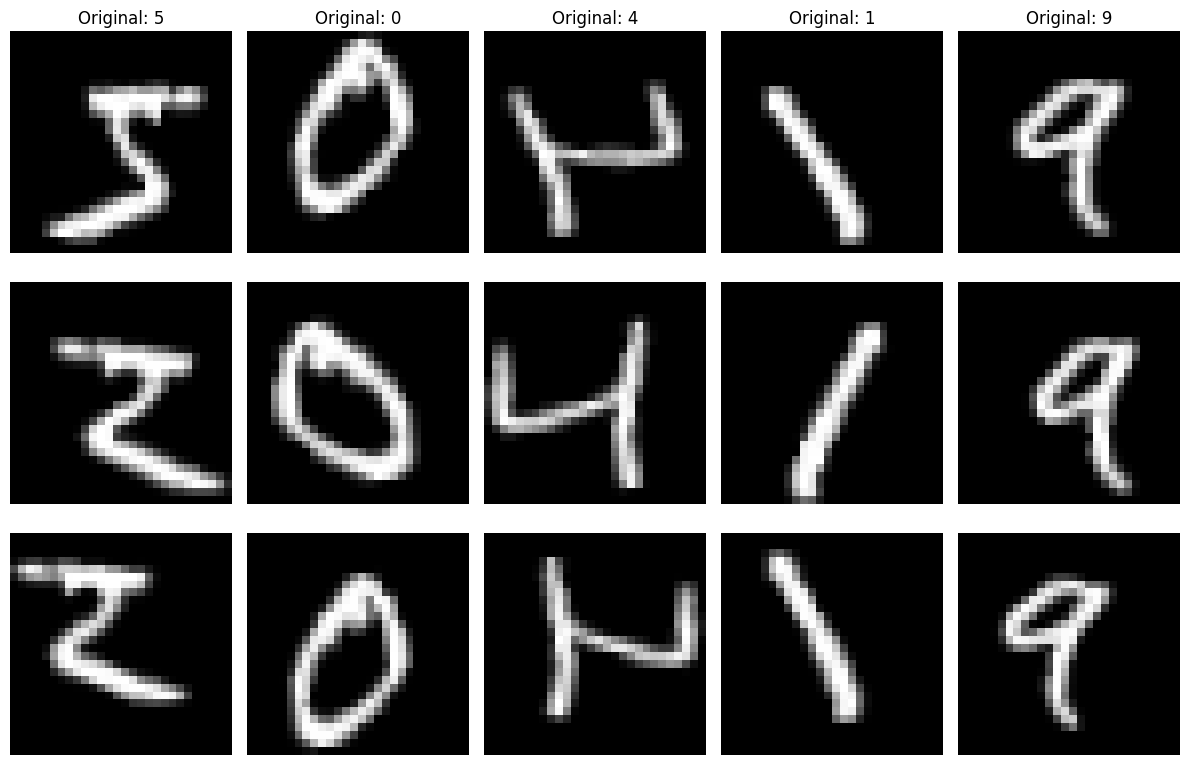

In [32]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [33]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [34]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

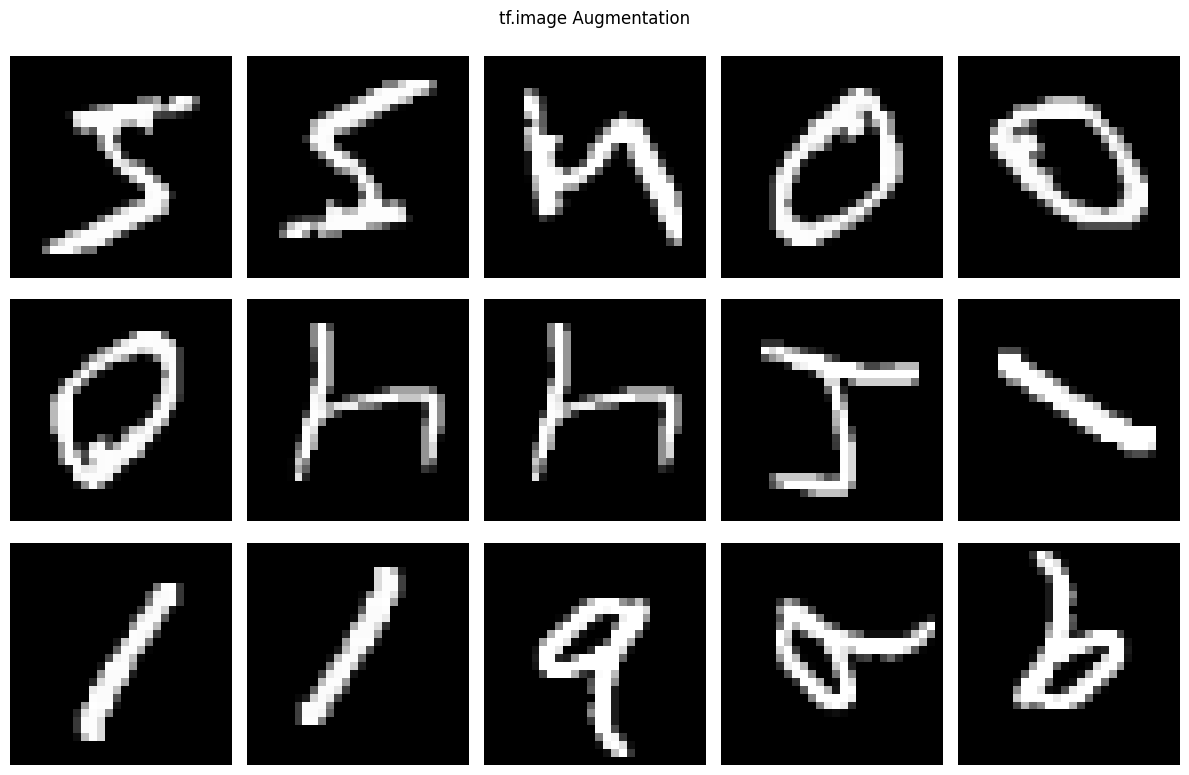

In [35]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [36]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

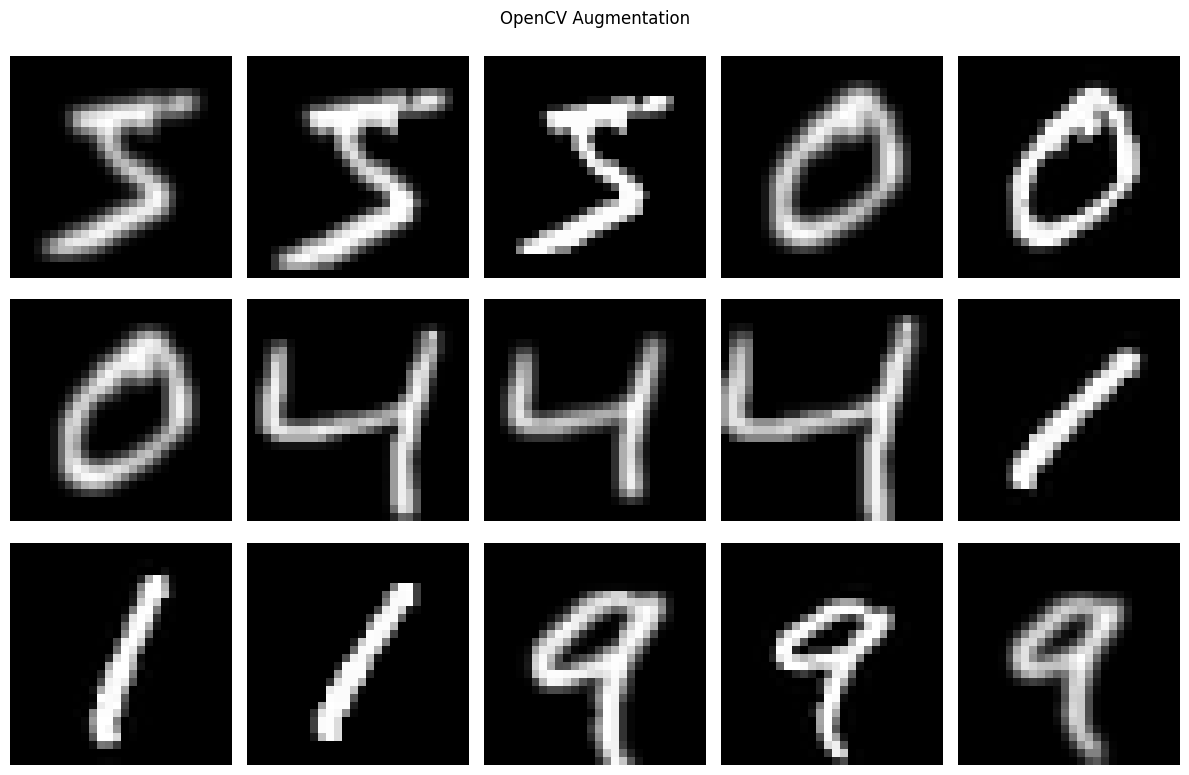

In [37]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

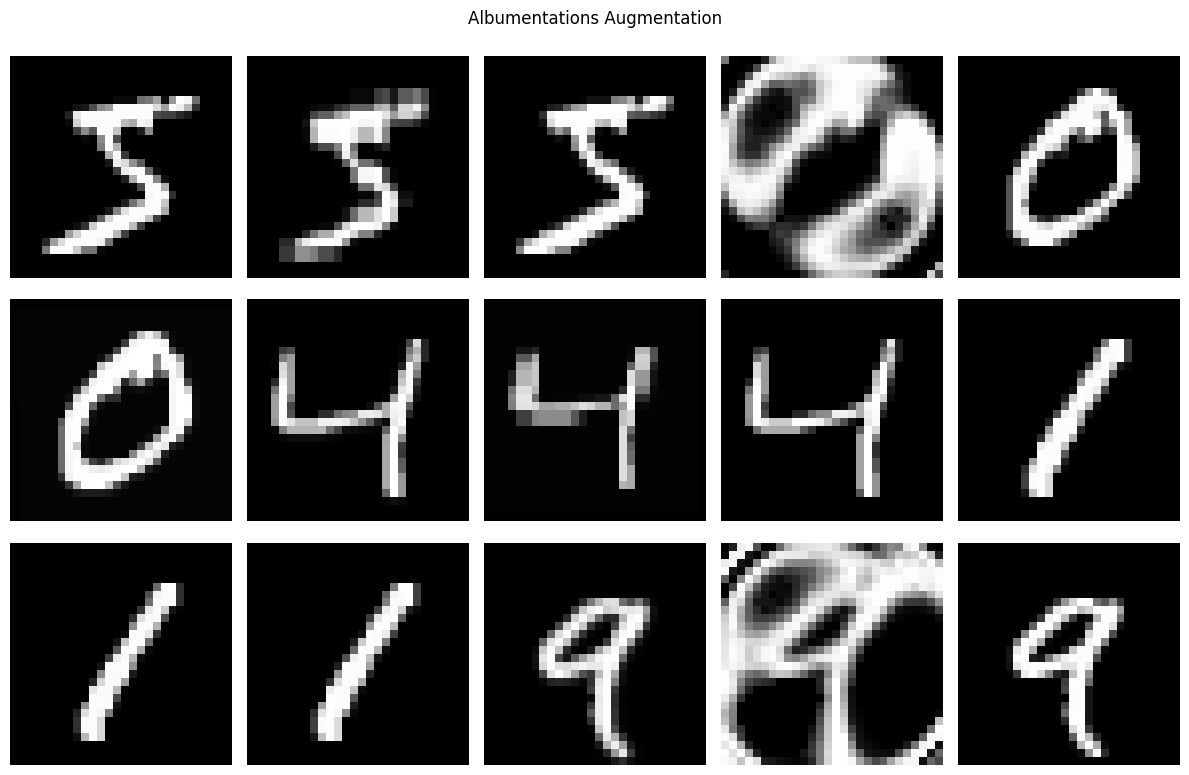

In [38]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [39]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [40]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [41]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [42]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: This is great a product, I love it!
Word Deletion: This a great product, I love it!
Word Insertion: This is a great product, I love very it!
Original: The service was terrible and I'm disappointed.
Word Swap: The was service terrible and I'm disappointed.
Word Deletion: The service was terrible and I'm
Word Insertion: The service very was terrible and I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: I'm how sure not I feel about this experience.
Word Deletion: I'm not sure how I about this experience.
Word Insertion: I'm not sure how I feel about this quite experience.
Original: The food was delicious and the staff was friendly.
Word Swap: The food was staff and the delicious was friendly.
Word Deletion: The food was delicious and the was friendly.
Word Insertion: The food was delicious and the quite staff was friendly.
Original: This movie is boring and too l

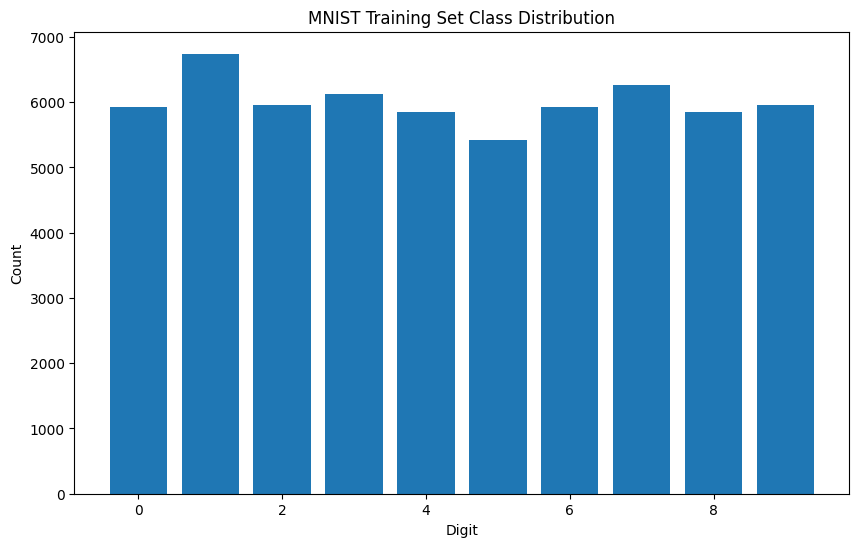

In [43]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [44]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [45]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [46]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [47]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [48]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [49]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [50]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [51]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [52]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

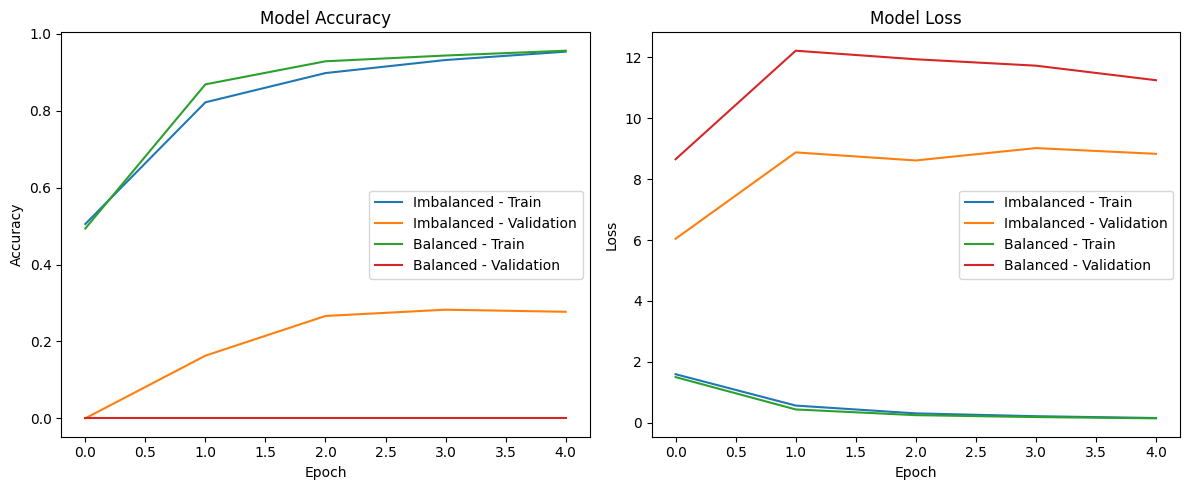

In [53]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Excercise

In [54]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TODO: Load the Titanic dataset into `df` using pd.read_csv
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)

# TODO: Display first 5 rows and the dataset shape
print(df.head())

# TODO: Print missing value counts per column

# Display dataset shape
print("Dataset Shape:", df.shape)

# Print missing value counts per column
print("\nMissing Values:")
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Da

In [55]:
# 2. Missing Value Imputation
# TODO: Fill missing 'Age' with its median
df['Age'] = df['Age'].fillna(df['Age'].median())

# TODO: Fill missing 'Embarked' with its mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# TODO: Replace missing 'Cabin' entries with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')


In [56]:
# 3. Feature Engineering

# 3.1 Extract Title from Name
# TODO: Create df['Title'] by extracting the substring before '.' in Name
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 3.2 Group rare titles into 'Rare' and standardize variants
# TODO: Replace rare and variant titles accordingly
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr','Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss','Ms': 'Miss','Mme': 'Mrs'})


# 3.3 Family Size and IsAlone
# TODO: df['FamilySize'] = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# TODO: df['IsAlone'] = 1 where FamilySize == 1, else 0
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)


# 3.4 Fare Per Person
# TODO: df['FarePerPerson'] = Fare / FamilySize
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
# TODO: Create AgeBin categories: Child (0–12), Teenager (13–18), Adult (19–65), Elderly (>65)
df['AgeBin'] = pd.cut(df['Age'],bins=[0, 12, 18, 65, np.inf],labels=['Child', 'Teenager', 'Adult', 'Elderly'])


# TODO: Create FareBin quantiles: Low, Medium, High, Very High
df['FareBin'] = pd.qcut(df['Fare'],q=4,labels=['Low', 'Medium', 'High', 'Very High'])

# 3.6 Deck from Cabin
# TODO: df['Deck'] = first letter of Cabin; replace 'Unknown'→'U' and rare letters→'Other'

# Extract the first letter of Cabin ('Unknown' automatically becomes 'U')
df['Deck'] = df['Cabin'].str[0]

# Group rare deck letters into 'Other'
rare_decks = ['T', 'G']
df['Deck'] = df['Deck'].replace(rare_decks, 'Other')


In [57]:
# 4. Encoding and Scaling

# 4.1 One‑hot encode selected categorical columns using pd.get_dummies :contentReference[oaicite:11]{index=11}
categorical = ['Pclass','Sex','Embarked','Title','AgeBin','FareBin','Deck']

# TODO: df_encoded = pd.get_dummies(df[categorical], drop_first=True)
df_encoded = pd.get_dummies(df[categorical], drop_first=True)

# 4.2 Combine with numerical features
numerical = ['Age','SibSp','Parch','Fare','FamilySize','IsAlone','FarePerPerson']
# TODO: X = pd.concat([...], axis=1)
X = pd.concat([df[numerical], df_encoded], axis=1)

# TODO: y = df['Survived']
y = df['Survived']


# 4.3 Feature scaling: fit three different scalers and transform X
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# TODO: scaler_std = StandardScaler()
scaler_std = StandardScaler()

# TODO: scaler_mm  = MinMaxScaler()
scaler_mm  = MinMaxScaler()

# TODO: scaler_rbv = RobustScaler()
scaler_rbv = RobustScaler()


# TODO: X_std = scaler_std.fit_transform(X)
X_std = scaler_std.fit_transform(X)

# TODO: X_mm  = scaler_mm.fit_transform(X)
X_mm  = scaler_mm.fit_transform(X)

# TODO: X_rb  = scaler_rbv.fit_transform(X)
X_rb  = scaler_rbv.fit_transform(X)

In [58]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# TODO: Use SelectKBest(f_classif, k=15) to pick top features :contentReference[oaicite:13]{index=13}
selector = SelectKBest(score_func=f_classif, k=15)

# TODO: X_sel = selector.fit_transform(X_std, y)
X_sel = selector.fit_transform(X_std, y)

# TODO: top_feats = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_}).nlargest(15,'Score')
top_feats = pd.DataFrame({'Feature': X.columns,'Score': selector.scores_}).nlargest(15, 'Score')

print(top_feats)

# TODO: Split into train/test (25% test), train RandomForestClassifier, and print:
#       - Accuracy
#       - Classification report
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_sel,
    y,
    test_size=0.25,
    random_state=42
)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
27             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
21             Deck_B   28.117228
23             Deck_D   20.663186
10         Embarked_S   20.374460
24             Deck_E   19.179221
22             Deck_C   11.841661
Accuracy: 0.8071748878923767

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       134
           1       0.74      0.80      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


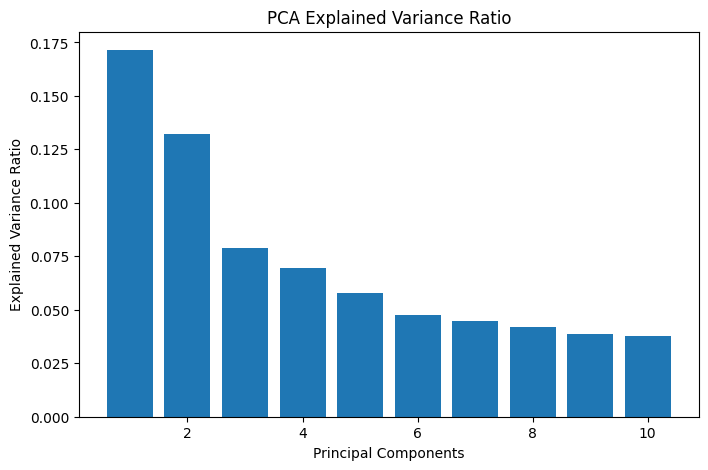

Cumulative Explained Variance:
[0.17143027 0.30356079 0.38257186 0.45194478 0.50977451 0.55713263
 0.60189523 0.64381557 0.68257732 0.72014198]


In [59]:
# 6. Advanced Feature Engineering

# 6.1 Polynomial Features using sklearn.preprocessing.PolynomialFeatures :contentReference[oaicite:14]{index=14}
from sklearn.preprocessing import PolynomialFeatures

# TODO: poly = PolynomialFeatures(degree=2, include_bias=False)
poly = PolynomialFeatures(degree=2, include_bias=False)

# TODO: poly_data = poly.fit_transform(df[['Age','Fare']].fillna(0))
poly_data = poly.fit_transform(df[['Age','Fare']].fillna(0))

# TODO: print(poly.get_feature_names_out(['Age','Fare']))
print(poly.get_feature_names_out(['Age','Fare']))


# 6.2 PCA for dimensionality reduction :contentReference[oaicite:15]{index=15}
from sklearn.decomposition import PCA
# TODO: pca = PCA(n_components=10)
pca = PCA(n_components=10)

# TODO: X_pca = pca.fit_transform(X_std)
X_pca = pca.fit_transform(X_std)

# TODO: Plot explained variance ratio bar chart
plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.show()

# TODO: Print cumulative variance (np.cumsum)
print("Cumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))


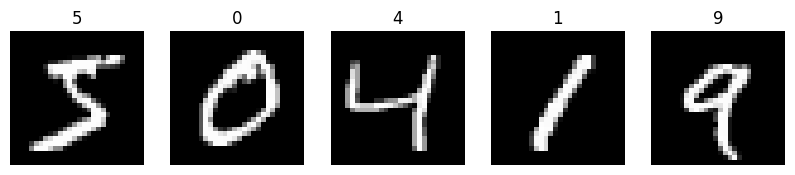

In [60]:
# 7. Image Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # :contentReference[oaicite:16]{index=16}
from tensorflow.keras.datasets import mnist

# TODO: Load MNIST, normalize, and reshape to (28,28,1)
# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape to (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# TODO: Display 5 sample images with true labels
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()



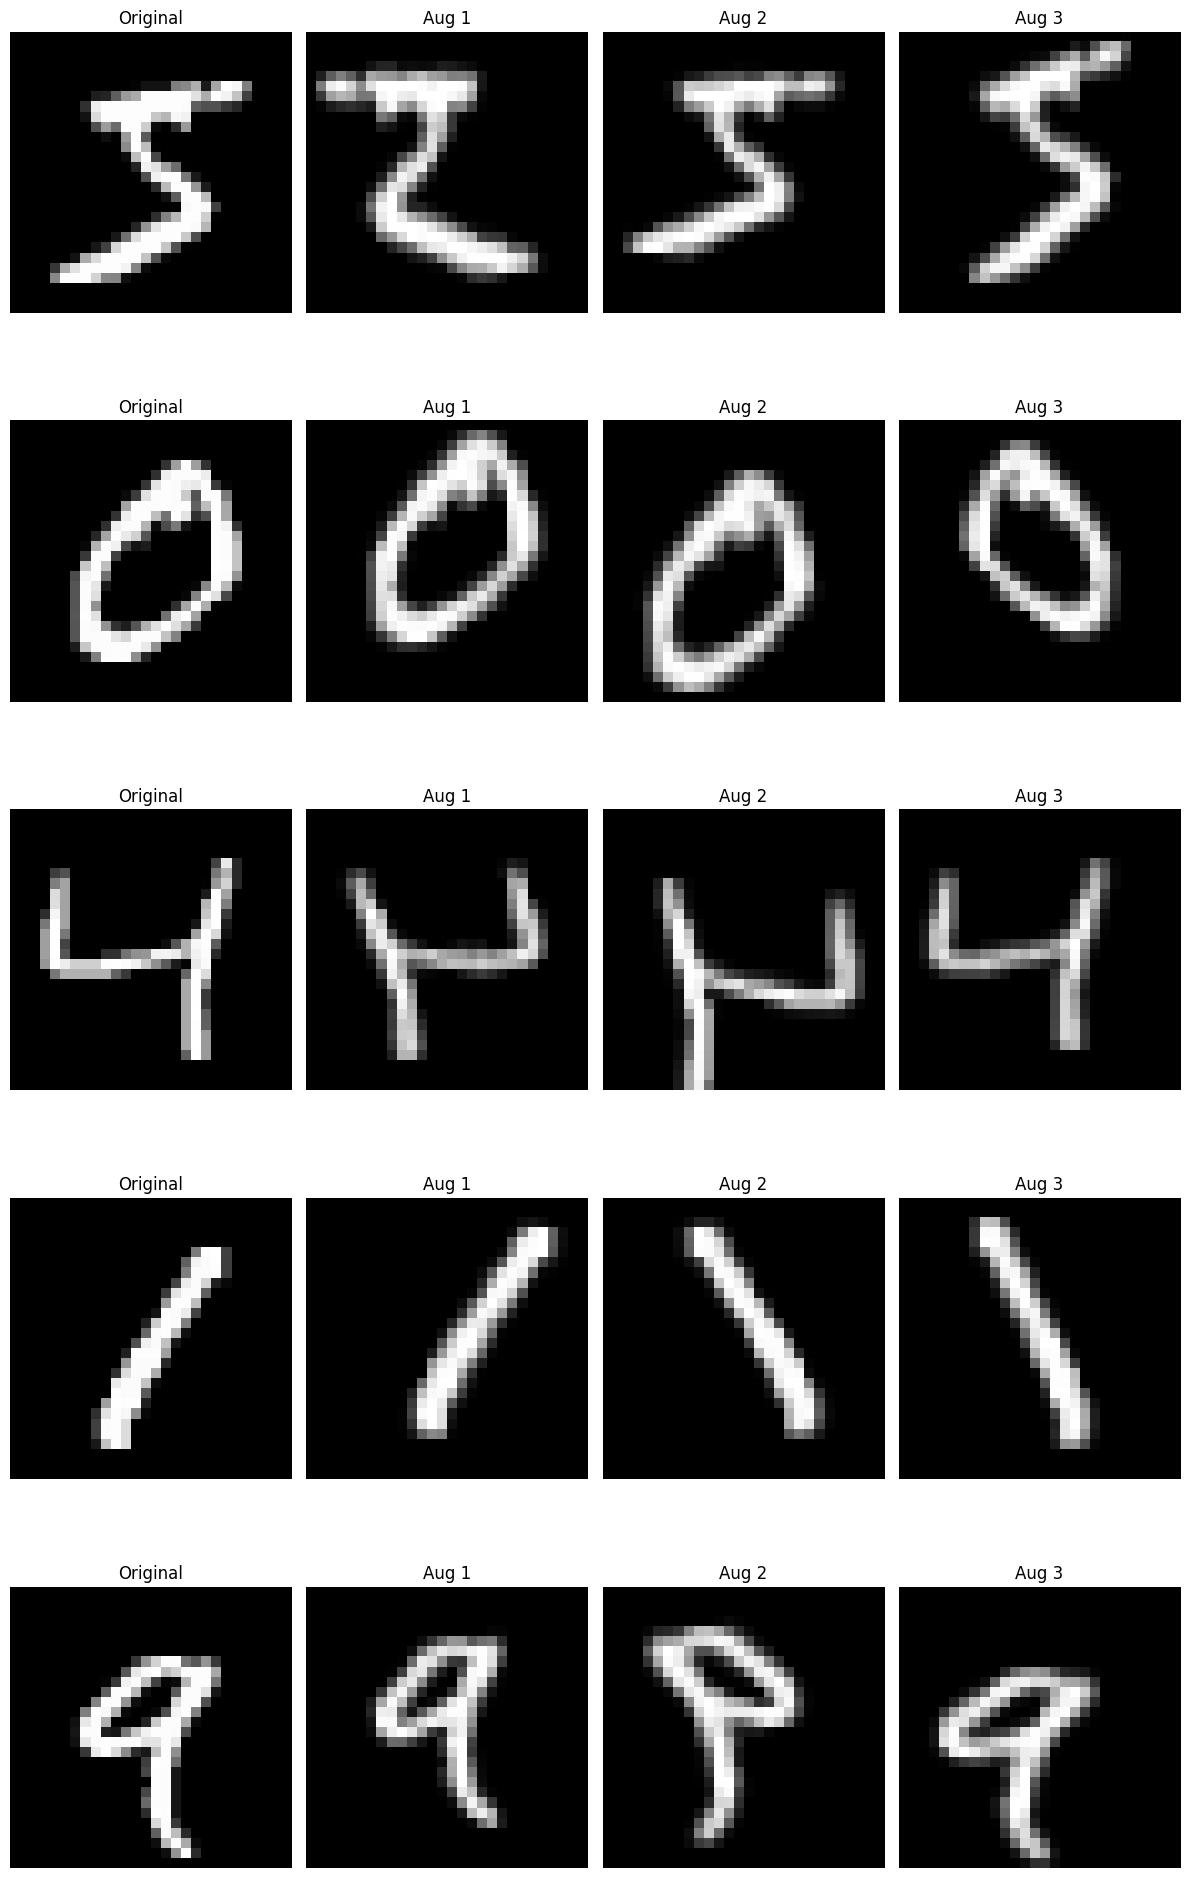

In [61]:
# 7.1 Keras ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1,
                             shear_range=0.1,
                            #  brightness_range=[0.5,1.5],
                             horizontal_flip=True,
                             fill_mode='nearest')
# TODO: Generate and plot 3 augmentations per sample for first 5 images
plt.figure(figsize=(12,20))

plot_index = 1

for i in range(5):

    image = X_train[i].reshape(1,28,28,1)

    generator = datagen.flow(image, batch_size=1)

    # Original image
    plt.subplot(5,4,plot_index)
    plt.imshow(image[0].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")
    plot_index += 1

    # Three augmented images
    for j in range(3):

        aug_image = next(generator)[0]

        plt.subplot(5,4,plot_index)
        plt.imshow(aug_image.reshape(28,28), cmap="gray")
        plt.title(f"Aug {j+1}")
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

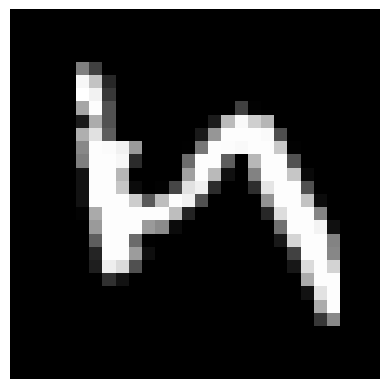

In [62]:
# 7.2 tf.image augmentations :contentReference[oaicite:17]{index=17}
import tensorflow as tf
# TODO: Write a function using tf.image.rot90, tf.image.random_brightness, tf.image.random_contrast

def tf_augment(image):

    image = tf.image.rot90(image)

    image = tf.image.random_brightness(
        image,
        max_delta=0.2
    )

    image = tf.image.random_contrast(
        image,
        lower=0.8,
        upper=1.2
    )

    return image

aug = tf_augment(X_train[0])

plt.imshow(tf.squeeze(aug), cmap="gray")
plt.axis("off")
plt.show()

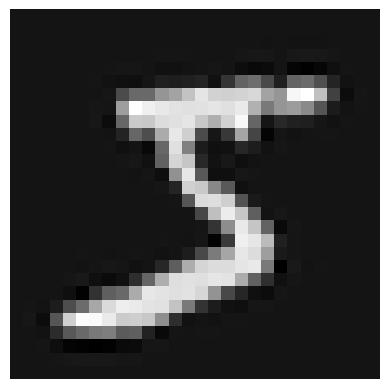

In [63]:

# 7.3 OpenCV augmentations :contentReference[oaicite:18]{index=18}
import cv2
from scipy import ndimage
import random
# TODO: Write opencv_augment() that randomly applies rotate, blur, or zoom

def opencv_augment(image):

    image = image.squeeze()

    choice = random.choice(["rotate", "blur", "zoom"])

    if choice == "rotate":
        angle = random.randint(-20,20)
        image = ndimage.rotate(image, angle, reshape=False)

    elif choice == "blur":
        image = cv2.GaussianBlur(image, (3,3), 0)

    elif choice == "zoom":

        h, w = image.shape

        crop = image[3:25, 3:25]

        image = cv2.resize(crop, (w,h))

    return image

img = opencv_augment(X_train[0])

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

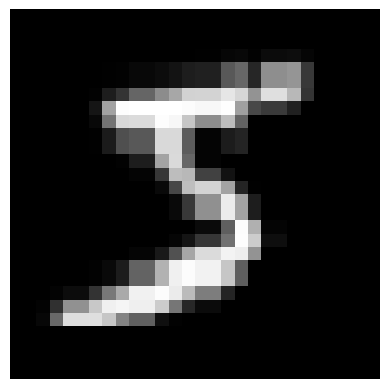

In [64]:
# 7.4 Albumentations pipeline :contentReference[oaicite:19]{index=19}
import albumentations as A
# TODO: Define A.Compose with RandomBrightnessContrast, ElasticTransform, GridDistortion, OpticalDistortion

transform = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5)
])

image = X_train[0].squeeze()

augmented = transform(image=image)

plt.imshow(augmented["image"], cmap="gray")
plt.axis("off")
plt.show()

In [65]:
# 8. Text Data Augmentation

import random  # :contentReference[oaicite:20]{index=20}

# Sample sentences provided
texts = [
    "I love machine learning",
    "Python is easy to learn",
    "Data science is very interesting"
]



# TODO: Implement swap_words(text), delete_random_word(text), insert_random_word(text)
# Swap two random words
def swap_words(text):
    words = text.split()

    if len(words) < 2:
        return text

    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]

    return " ".join(words)


# Delete one random word
def delete_random_word(text):
    words = text.split()

    if len(words) <= 1:
        return text

    idx = random.randint(0, len(words) - 1)
    words.pop(idx)

    return " ".join(words)


# Insert a random existing word at a random position
def insert_random_word(text):
    words = text.split()

    word = random.choice(words)
    idx = random.randint(0, len(words))

    words.insert(idx, word)

    return " ".join(words)


# TODO: For each original text, print the 3 augmented variants

# Print augmented versions
for text in texts:

    print("Original :", text)
    print("Swap     :", swap_words(text))
    print("Delete   :", delete_random_word(text))
    print("Insert   :", insert_random_word(text))
    print("-" * 50)

Original : I love machine learning
Swap     : machine love I learning
Delete   : I love machine
Insert   : I love love machine learning
--------------------------------------------------
Original : Python is easy to learn
Swap     : Python is learn to easy
Delete   : is easy to learn
Insert   : Python is easy to learn easy
--------------------------------------------------
Original : Data science is very interesting
Swap     : Data science is interesting very
Delete   : Data science is interesting
Insert   : Data science science is very interesting
--------------------------------------------------


In [66]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# TODO: Compute class distribution of y_train_img

# Use MNIST training data
X_train_img = X_train
y_train_img = y_train

# Compute class distribution
unique, counts = np.unique(y_train_img, return_counts=True)

print("Class Distribution:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")


# ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

# TODO: Write augment_minority_class(X, y, target_class, num_samples) that:
#         – Finds indices for target_class
#         – Uses ImageDataGenerator.flow to generate until desired count
#         – Returns augmented X_balanced, y_balanced
def augment_minority_class(X, y, target_class, num_samples):

    # Find indices of target class
    indices = np.where(y == target_class)[0]

    X_target = X[indices]
    y_target = y[indices]

    X_augmented = []
    y_augmented = []

    generator = datagen.flow(
        X_target,
        y_target,
        batch_size=1,
        shuffle=True
    )

    while len(X_augmented) < num_samples:

        image, label = next(generator)

        X_augmented.append(image[0])
        y_augmented.append(label[0])

    X_balanced = np.concatenate([X, np.array(X_augmented)], axis=0)
    y_balanced = np.concatenate([y, np.array(y_augmented)], axis=0)

    return X_balanced, y_balanced

Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


In [67]:
X_balanced, y_balanced = augment_minority_class(
    X_train_img,
    y_train_img,
    target_class=0,
    num_samples=1000
)

print("Original Shape:", X_train_img.shape)
print("Balanced Shape:", X_balanced.shape)

Original Shape: (60000, 28, 28, 1)
Balanced Shape: (61000, 28, 28, 1)


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.4848 - loss: 1.6738 - val_accuracy: 0.7405 - val_loss: 1.0758
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.8359 - loss: 0.5375 - val_accuracy: 0.8317 - val_loss: 0.5385
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9152 - loss: 0.3055 - val_accuracy: 0.8735 - val_loss: 0.4125
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9478 - loss: 0.2087 - val_accuracy: 0.8778 - val_loss: 0.4061
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.9511 - loss: 0.1544 - val_accuracy: 0.9068 - val_loss: 0.3057
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.6010 - loss: 1.4911 - val_accuracy: 0.8000 - val_loss: 0.6434
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8550 - loss: 0.4630 - val_accuracy: 0.8819 - val_loss: 0.3898
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.9230 - loss: 0.2866 - val_accuracy: 0.9069 - v

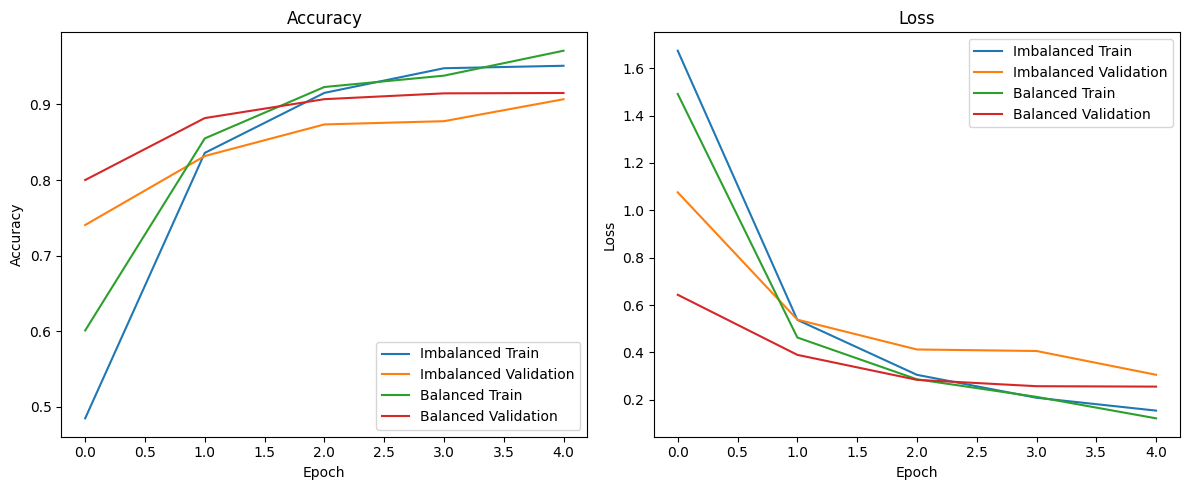

In [68]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf

# TODO: Define create_model() as simple CNN
def create_model():

    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# TODO: Train on imbalanced subset (e.g. first 100 per class minus some for class '8')
X_imbalanced = []
y_imbalanced = []

for cls in range(10):

    idx = np.where(y_train == cls)[0]

    if cls == 8:
        idx = idx[:20]          # Minority class
    else:
        idx = idx[:100]

    X_imbalanced.append(X_train[idx])
    y_imbalanced.append(y_train[idx])

X_imbalanced = np.concatenate(X_imbalanced)
y_imbalanced = np.concatenate(y_imbalanced)

# Train on Imbalanced Data
model1 = create_model()

history1 = model1.fit(
    X_imbalanced,
    y_imbalanced,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

# Balance the Data Using Previous Function
X_balanced, y_balanced = augment_minority_class(
    X_imbalanced,
    y_imbalanced,
    target_class=8,
    num_samples=80
)

# TODO: Train on balanced data after augmentation
model2 = create_model()

history2 = model2.fit(
    X_balanced,
    y_balanced,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

# TODO: Plot training/validation accuracy and loss side by side
# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history1.history['accuracy'], label='Imbalanced Train')
plt.plot(history1.history['val_accuracy'], label='Imbalanced Validation')

plt.plot(history2.history['accuracy'], label='Balanced Train')
plt.plot(history2.history['val_accuracy'], label='Balanced Validation')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1,2,2)

plt.plot(history1.history['loss'], label='Imbalanced Train')
plt.plot(history1.history['val_loss'], label='Imbalanced Validation')

plt.plot(history2.history['loss'], label='Balanced Train')
plt.plot(history2.history['val_loss'], label='Balanced Validation')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**Experiment: feel free to tweak parameters (e.g., k in SelectKBest, PCA components, augmentation ranges) to see their impact.**